# Relax Challenge
This challenge contains the following data files:

1. A user table ( "takehome_users" ) with data on 12,000 users who signed up for the product in the last two years.
2. A usage summary table ( "takehome_user_engagement" ) that has a row for each day that a user logged into the product. 

Defining an "adopted user" as a user who has logged into the product on three separate days in at least one sevenday period, identify which factors predict future user adoption . 

We suggest spending 1-2 hours on this, but you're  welcome to spend more or less. Please send us a brief writeup of your findings (the more concise, the better no more than one page), along with any summary tables, graphs, code, or queries that can help us understand your approach. Please note any factors you considered or investigation you did, even if they did not pan out.   Feel free to identify any further research or data you think would be valuable. 


In [31]:
# import packages
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns


#import sklearn packages
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

#import metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.inspection import permutation_importance



In [2]:
#import data
users_df = pd.read_csv('takehome_users.csv', encoding='latin-1', index_col='object_id')
engagement_df = pd.read_csv('takehome_user_engagement.csv')

In [3]:
users_df.head()

,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
object_id,,,,,,,,,
1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0
2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0
3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0
4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0
5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0


In [4]:
users_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 1 to 12000
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   creation_time               12000 non-null  object 
 1   name                        12000 non-null  object 
 2   email                       12000 non-null  object 
 3   creation_source             12000 non-null  object 
 4   last_session_creation_time  8823 non-null   float64
 5   opted_in_to_mailing_list    12000 non-null  int64  
 6   enabled_for_marketing_drip  12000 non-null  int64  
 7   org_id                      12000 non-null  int64  
 8   invited_by_user_id          6417 non-null   float64
dtypes: float64(2), int64(3), object(4)
memory usage: 937.5+ KB


In [5]:
#identify the number of unique org_ids and invited_by_user_id
print(users_df['org_id'].nunique())
print(users_df['invited_by_user_id'].nunique())


417
2564


In [6]:
#detemine if there missing values in the dataframe
users_df.isnull().sum()


creation_time                    0
name                             0
email                            0
creation_source                  0
last_session_creation_time    3177
opted_in_to_mailing_list         0
enabled_for_marketing_drip       0
org_id                           0
invited_by_user_id            5583
dtype: int64

In [7]:
users_df.describe()

,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
count,8.823000e+03,12000.000000,12000.000000,12000.000000,6417.000000
mean,1.379279e+09,0.249500,0.149333,141.884583,5962.957145
std,1.953116e+07,0.432742,0.356432,124.056723,3383.761968
min,1.338452e+09,0.000000,0.000000,0.000000,3.000000
25%,1.363195e+09,0.000000,0.000000,29.000000,3058.000000
50%,1.382888e+09,0.000000,0.000000,108.000000,5954.000000
75%,1.398443e+09,0.000000,0.000000,238.250000,8817.000000
max,1.402067e+09,1.000000,1.000000,416.000000,11999.000000


Data scrubbing needed for the users file include the following:
* converting the creation_time and last_session_creation_times to datetime formats
* handling the null values within the last_session_creation_time field (replace the nulls with creation_time value, assuming that was the last time they may have loggedin)
* create a new field that specifies that the last_session_creation_time was null to identify that they were modified.
* we can also drop the unnecessary fields such as name, email.  There could be value in the invited by user id field, however with one-hot encoding that will greatly increase the dimensionality of the dataset.  For purposes of this exercise, we will drop it too.  The org_id is a bit more manageable with only 417 values.

In [8]:
#convert the creation_time and last_session_creation_time to datetime
users_df['creation_time'] = pd.to_datetime(users_df['creation_time'])
users_df['last_session_creation_time'] = pd.to_datetime(users_df['last_session_creation_time'], unit='s')

In [9]:
#fill the null values in last_session_creation_time with the creation_time
users_df['last_session_creation_time'] = users_df['last_session_creation_time'].fillna(users_df['creation_time'])


In [10]:
#create a new column indicating that last_session_creation_time was replaced with creation time where last_session_creation_time equals creation_time
users_df['last_session_creation_time_replaced'] = users_df['last_session_creation_time'] == users_df['creation_time']

users_df.head()


,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,last_session_creation_time_replaced
object_id,,,,,,,,,,
1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,2014-04-22 03:53:30,1,0,11,10803.0,True
2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,2014-03-31 03:45:04,0,0,1,316.0,False
3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,2013-03-19 23:14:52,0,0,94,1525.0,True
4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,2013-05-22 08:09:28,0,0,1,5151.0,False
5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,2013-01-22 10:14:20,0,0,193,5240.0,False


In [11]:
#drop the name, email and invited_by_user_id columns from the dataframe
users_df = users_df.drop(columns=['name', 'email', 'invited_by_user_id'])


In [12]:
users_df.head()

,creation_time,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,last_session_creation_time_replaced
object_id,,,,,,,
1,2014-04-22 03:53:30,GUEST_INVITE,2014-04-22 03:53:30,1,0,11,True
2,2013-11-15 03:45:04,ORG_INVITE,2014-03-31 03:45:04,0,0,1,False
3,2013-03-19 23:14:52,ORG_INVITE,2013-03-19 23:14:52,0,0,94,True
4,2013-05-21 08:09:28,GUEST_INVITE,2013-05-22 08:09:28,0,0,1,False
5,2013-01-17 10:14:20,GUEST_INVITE,2013-01-22 10:14:20,0,0,193,False


In [13]:
engagement_df.head()

,time_stamp,user_id,visited
0,2014-04-22 03:53:30,1,1
1,2013-11-15 03:45:04,2,1
2,2013-11-29 03:45:04,2,1
3,2013-12-09 03:45:04,2,1
4,2013-12-25 03:45:04,2,1


In [14]:
engagement_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207917 entries, 0 to 207916
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   time_stamp  207917 non-null  object
 1   user_id     207917 non-null  int64 
 2   visited     207917 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 4.8+ MB


In [15]:
#determine the number of unique values for each field in the engagement dataframe
print(engagement_df['user_id'].nunique())   
print(engagement_df['time_stamp'].nunique())

8823
207220


In [16]:
#only the timestamp column needs to be converted to datetime no other columns need to be converted
engagement_df['time_stamp'] = pd.to_datetime(engagement_df['time_stamp'])

In [17]:
engagement_df.head()

,time_stamp,user_id,visited
0,2014-04-22 03:53:30,1,1
1,2013-11-15 03:45:04,2,1
2,2013-11-29 03:45:04,2,1
3,2013-12-09 03:45:04,2,1
4,2013-12-25 03:45:04,2,1


The challenge calls for us to flag the users as an "adopted user" if at any point, they logged into the platform 3 times within a 7 day window.  We will sort the data first by user and then by the time_stamp field.  We will then create a new column that provides a count of the number of visits for a rolling 7 days.  We can then create a new dataframe that shows the user_id and their adopted user status.  

We can create another feature for the number of visits to the site, as this could provide some predictive value to the prediction model.

In [18]:
#sort the dataframe by time_stamp and user_id
engagement_df = engagement_df.sort_values(by=['time_stamp', 'user_id'])

In [19]:
#set the engagment timestamp and user_id as the index of the dataframe
engagement_df = engagement_df.set_index(['time_stamp', 'user_id'])
 
#sort the dataframe by the new index
engagement_df = engagement_df.sort_index()

In [20]:
engagement_df.head()

,,visited
time_stamp,user_id,
2012-05-31 08:20:06,10012,1
2012-05-31 15:47:36,3428,1
2012-05-31 17:19:37,9899,1
2012-05-31 21:58:33,1693,1
2012-06-01 00:17:30,6102,1


In [21]:
#define my rolling window value as 7 days. This will be used to calculate the sum of the visited column for each user_id over a 7 day period
rolling_window = '7D'

#create a new field that contains the sum of the visited column a rolling 7 day period for each time_stamp and user_id
engagement_df['rolling_sum'] = (engagement_df.groupby(level='user_id')['visited']
                          .rolling(rolling_window, closed='both', on=engagement_df.index.get_level_values('time_stamp'))
                          .sum()
                          .droplevel(0))  # Drop the extra user_id level from the index

#reset the index of the dataframe
engagement_df = engagement_df.reset_index()

#display the new dataframe sorted by user_id and time_stamp

engagement_df.sort_values(by=['user_id', 'time_stamp']).head(15)



,time_stamp,user_id,visited,rolling_sum
180324,2014-04-22 03:53:30,1,1,1.0
95991,2013-11-15 03:45:04,2,1,1.0
102076,2013-11-29 03:45:04,2,1,1.0
106638,2013-12-09 03:45:04,2,1,1.0
114201,2013-12-25 03:45:04,2,1,1.0
117157,2013-12-31 03:45:04,2,1,2.0
121166,2014-01-08 03:45:04,2,1,1.0
134650,2014-02-03 03:45:04,2,1,1.0
137324,2014-02-08 03:45:04,2,1,2.0
137845,2014-02-09 03:45:04,2,1,3.0


In [22]:
#filter the dataframe to remove duplicate rows.  Each user only needs to appear once in the new dataframe.  We will use the max value for the rolling_sum column
adopted_users_df = engagement_df.groupby('user_id').agg({'visited': 'sum', 'rolling_sum': 'max'})

#create "adopted_user" column in the engagement_df. If the value for rolling_sum is greater than or equal to 3 then the user is an adopted user, else they are not an adopted user
adopted_users_df['adopted_user'] = adopted_users_df['rolling_sum'] >= 3

#display the new dataframe
adopted_users_df.head()




,visited,rolling_sum,adopted_user
user_id,,,
1,1,1.0,False
2,14,3.0,True
3,1,1.0,False
4,1,1.0,False
5,1,1.0,False


In [23]:
#we can now merge the two dataframes on the object_id field in the users_df dataframe and the user_id field in the adopted_users_df dataframe
users_df = users_df.merge(adopted_users_df, how='left', left_index=True, right_index=True)
users_df.head(10)

,creation_time,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,last_session_creation_time_replaced,visited,rolling_sum,adopted_user
object_id,,,,,,,,,,
1,2014-04-22 03:53:30,GUEST_INVITE,2014-04-22 03:53:30,1,0,11,True,1.0,1.0,False
2,2013-11-15 03:45:04,ORG_INVITE,2014-03-31 03:45:04,0,0,1,False,14.0,3.0,True
3,2013-03-19 23:14:52,ORG_INVITE,2013-03-19 23:14:52,0,0,94,True,1.0,1.0,False
4,2013-05-21 08:09:28,GUEST_INVITE,2013-05-22 08:09:28,0,0,1,False,1.0,1.0,False
5,2013-01-17 10:14:20,GUEST_INVITE,2013-01-22 10:14:20,0,0,193,False,1.0,1.0,False
6,2013-12-17 03:37:06,GUEST_INVITE,2013-12-19 03:37:06,0,0,197,False,1.0,1.0,False
7,2012-12-16 13:24:32,SIGNUP,2012-12-20 13:24:32,0,1,37,False,1.0,1.0,False
8,2013-07-31 05:34:02,PERSONAL_PROJECTS,2013-07-31 05:34:02,1,1,74,True,NaN,NaN,NaN
9,2013-11-05 04:04:24,PERSONAL_PROJECTS,2013-11-05 04:04:24,0,0,302,True,NaN,NaN,NaN


In [24]:
#we will also create categorical values for the Year, Month, and Day of the week for the creation_time field as these may impact whether or not a user becomes an adopted user
users_df['creation_year'] = users_df['creation_time'].dt.year
users_df['creation_month'] = users_df['creation_time'].dt.month
users_df['creation_day'] = users_df['creation_time'].dt.dayofweek

#cast these as categorical values
users_df['creation_year'] = users_df['creation_year'].astype('category')
users_df['creation_month'] = users_df['creation_month'].astype('category')
users_df['creation_day'] = users_df['creation_day'].astype('category')    

users_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 1 to 12000
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   creation_time                        12000 non-null  datetime64[ns]
 1   creation_source                      12000 non-null  object        
 2   last_session_creation_time           12000 non-null  datetime64[ns]
 3   opted_in_to_mailing_list             12000 non-null  int64         
 4   enabled_for_marketing_drip           12000 non-null  int64         
 5   org_id                               12000 non-null  int64         
 6   last_session_creation_time_replaced  12000 non-null  bool          
 7   visited                              8823 non-null   float64       
 8   rolling_sum                          8823 non-null   float64       
 9   adopted_user                         8823 non-null   object        
 10  creation_year  

In [25]:
#in this situation, we will assume the NaN values should be replaced with 0 for visited and rolling_sum and false for adopted user, as it is likely the user has not enganged with the platform since the initial creation time
users_df['visited'] = users_df['visited'].fillna(0)
users_df['rolling_sum'] = users_df['rolling_sum'].fillna(0)
users_df['adopted_user'] = users_df['adopted_user'].fillna(False)


users_df.head()


C:\Users\lasha\AppData\Local\Temp\ipykernel_17772\1295399435.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  users_df['adopted_user'] = users_df['adopted_user'].fillna(False)


,creation_time,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,last_session_creation_time_replaced,visited,rolling_sum,adopted_user,creation_year,creation_month,creation_day
object_id,,,,,,,,,,,,,
1,2014-04-22 03:53:30,GUEST_INVITE,2014-04-22 03:53:30,1,0,11,True,1.0,1.0,False,2014,4,1
2,2013-11-15 03:45:04,ORG_INVITE,2014-03-31 03:45:04,0,0,1,False,14.0,3.0,True,2013,11,4
3,2013-03-19 23:14:52,ORG_INVITE,2013-03-19 23:14:52,0,0,94,True,1.0,1.0,False,2013,3,1
4,2013-05-21 08:09:28,GUEST_INVITE,2013-05-22 08:09:28,0,0,1,False,1.0,1.0,False,2013,5,1
5,2013-01-17 10:14:20,GUEST_INVITE,2013-01-22 10:14:20,0,0,193,False,1.0,1.0,False,2013,1,3


In [26]:
#convert the boolean fields to integers
users_df['adopted_user'] = users_df['adopted_user'].astype(int)
users_df['last_session_creation_time_replaced'] = users_df['last_session_creation_time_replaced'].astype(int)

#create a feature containing the duration in days between creation time and last session creation time
users_df['creation_last_session_duration'] = (users_df['last_session_creation_time'] - users_df['creation_time']).dt.days

#drop the creation_time and last_session_creation_time columns, visited and rolling_sum column as we have already used this to determine if a user is an adopted user, and org_id to reduce dimensionality
users_df = users_df.drop(columns=['creation_time', 'last_session_creation_time', 'rolling_sum', 'visited', 'org_id'])

#we can now use one hot encoding on the dataframe to convert the categorical values to numerical values stored as integers
users_df = pd.get_dummies(users_df, drop_first=True, dtype=int)
users_df.head()



,opted_in_to_mailing_list,enabled_for_marketing_drip,last_session_creation_time_replaced,adopted_user,creation_last_session_duration,creation_source_ORG_INVITE,creation_source_PERSONAL_PROJECTS,creation_source_SIGNUP,creation_source_SIGNUP_GOOGLE_AUTH,creation_year_2013,...,creation_month_9,creation_month_10,creation_month_11,creation_month_12,creation_day_1,creation_day_2,creation_day_3,creation_day_4,creation_day_5,creation_day_6
object_id,,,,,,,,,,,,,,,,,,,,,
1,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,1,136,1,0,0,0,1,...,0,0,1,0,0,0,0,1,0,0
3,0,0,1,0,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
5,0,0,0,0,5,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0


In [27]:
#we will perform one last check to ensure there are no missing values in the dataframe
users_df.isnull().sum().sort_values(ascending=False)

opted_in_to_mailing_list               0
enabled_for_marketing_drip             0
creation_day_5                         0
creation_day_4                         0
creation_day_3                         0
creation_day_2                         0
creation_day_1                         0
creation_month_12                      0
creation_month_11                      0
creation_month_10                      0
creation_month_9                       0
creation_month_8                       0
creation_month_7                       0
creation_month_6                       0
creation_month_5                       0
creation_month_4                       0
creation_month_3                       0
creation_month_2                       0
creation_year_2014                     0
creation_year_2013                     0
creation_source_SIGNUP_GOOGLE_AUTH     0
creation_source_SIGNUP                 0
creation_source_PERSONAL_PROJECTS      0
creation_source_ORG_INVITE             0
creation_last_se

In [28]:
# create our X and y values for the model
X = users_df.drop(columns='adopted_user')   # X is all columns except 'adopted_user'
y = users_df['adopted_user']   # y is the 'adopted_user' column 

print('The shape of X and y is: ', X.shape, y.shape)

#split the data into training and test set 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42) # we will use 80% of the data for training and 20% for testing and a random state of 42 for reproducibility

#verify the shape of the training and test data
print('The shape of the training data is: ', X_train.shape, y_train.shape)
print('The shape of the test data is: ', X_test.shape, y_test.shape)



The shape of X and y is:  (12000, 27) (12000,)
The shape of the training data is:  (9600, 27) (9600,)
The shape of the test data is:  (2400, 27) (2400,)


In [29]:
X_train.describe()  # display the summary statistics for the training data

,opted_in_to_mailing_list,enabled_for_marketing_drip,last_session_creation_time_replaced,creation_last_session_duration,creation_source_ORG_INVITE,creation_source_PERSONAL_PROJECTS,creation_source_SIGNUP,creation_source_SIGNUP_GOOGLE_AUTH,creation_year_2013,creation_year_2014,...,creation_month_9,creation_month_10,creation_month_11,creation_month_12,creation_day_1,creation_day_2,creation_day_3,creation_day_4,creation_day_5,creation_day_6
count,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,...,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000,9600.000000
mean,0.249688,0.153229,0.518333,43.749792,0.354896,0.174063,0.174271,0.115625,0.475521,0.294063,...,0.075729,0.077396,0.078125,0.078125,0.136250,0.141458,0.148854,0.152500,0.140313,0.137813
std,0.432855,0.360227,0.499690,126.773969,0.478507,0.379183,0.379362,0.319791,0.499426,0.455644,...,0.264578,0.267232,0.268382,0.268382,0.343072,0.348512,0.355963,0.359524,0.347329,0.344721
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,1.000000,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,729.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


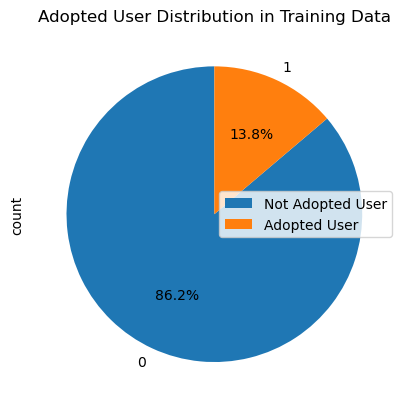

<Figure size 640x480 with 0 Axes>

In [30]:
#create a pie chart depicting the distribution of the target variable (adopted user) in the training data   
y_train.value_counts().plot.pie(autopct='%1.1f%%', startangle=90, title='Adopted User Distribution in Training Data')
#add a legend to the pie chart for Adopted User and Not Adopted User
plt.legend(['Not Adopted User', 'Adopted User'])
plt.show()

#write to svg file
plt.savefig('Adopted_User_Distribution_Training_Data.svg')

Logistic Regression Model

In [31]:
#Generate my logistic regression model  
lr = LogisticRegression(max_iter=1000)   

#fit my base model
lr.fit(X_train, y_train)

#base predictions
y_pred_lr = lr.predict(X_test)

#record base logistic regression metrics (accuracy score and classification report)
result_lr = accuracy_score(y_test, y_pred_lr)
cr_lr = classification_report(y_test, y_pred_lr, target_names=['Not Adopted User', 'Adopted User'])

#print accuracy score and classification report for base model
print("Accuracy score for base logistic regression model is: ", result_lr)
print("The classification report for the base logistic regression model:")
print(cr_lr)

Accuracy score for base logistic regression model is:  0.9704166666666667
The classification report for the base logistic regression model:
                  precision    recall  f1-score   support

Not Adopted User       0.98      0.99      0.98      2069
    Adopted User       0.92      0.86      0.89       331

        accuracy                           0.97      2400
       macro avg       0.95      0.93      0.94      2400
    weighted avg       0.97      0.97      0.97      2400



In [32]:
#the most important features for logistic regression model are:
feature_names = X_train.columns
importance_lr = lr.coef_[0]

#combine the feature names and importance into a dataframe
feature_importance_lr = pd.DataFrame({'feature': feature_names, 'importance': importance_lr})

#sort the dataframe by importance and display the top 10 features in descending order
feature_importance_lr = feature_importance_lr.sort_values(by='importance', ascending=False)
feature_importance_lr.head(10)

,feature,importance
24,creation_day_4,0.835535
26,creation_day_6,0.722852
9,creation_year_2014,0.673609
14,creation_month_6,0.554167
20,creation_month_12,0.535647
21,creation_day_1,0.533612
12,creation_month_4,0.456541
16,creation_month_8,0.408186
0,opted_in_to_mailing_list,0.301598
17,creation_month_9,0.245021


Random Forest Model

In [33]:
#Generate my random forest model  
rf = RandomForestClassifier()

#fit my random forest model
rf.fit(X_train, y_train)

#base predictions
y_pred_rf = rf.predict(X_test)

#record base random forest metrics (accuracy score and classification report)
result_rf = accuracy_score(y_test, y_pred_rf)
cr_rf = classification_report(y_test, y_pred_rf, target_names=['Not Adopted User', 'Adopted User'])

#print accuracy score and classification report for base model
print("Accuracy score for base random forest model is: ", result_rf)
print("The classification report for the base random forest model:")
print(cr_rf)

Accuracy score for base random forest model is:  0.9670833333333333
The classification report for the base random forest model:
                  precision    recall  f1-score   support

Not Adopted User       0.98      0.99      0.98      2069
    Adopted User       0.90      0.85      0.88       331

        accuracy                           0.97      2400
       macro avg       0.94      0.92      0.93      2400
    weighted avg       0.97      0.97      0.97      2400



In [34]:
#get the feature importances for the random forest model
importance_rf = rf.feature_importances_

#create a dataframe with the feature names and importances
feature_importance_rf = pd.DataFrame({'feature': feature_names, 'importance': importance_rf})

#sort the dataframe by importance and display the top 10 features in descending order
feature_importance_rf = feature_importance_rf.sort_values(by='importance', ascending=False)
feature_importance_rf.head(10)

,feature,importance
3,creation_last_session_duration,0.791043
2,last_session_creation_time_replaced,0.090970
0,opted_in_to_mailing_list,0.008884
4,creation_source_ORG_INVITE,0.008460
9,creation_year_2014,0.006959
7,creation_source_SIGNUP_GOOGLE_AUTH,0.006293
13,creation_month_5,0.005843
1,enabled_for_marketing_drip,0.005806
26,creation_day_6,0.005624
8,creation_year_2013,0.005574


K nearest neighbor model

In [35]:
#Generate my base model  (default params)
knn = KNeighborsClassifier()

#fit my base model
knn.fit(X_train, y_train)

#base predictions
y_pred_knn = knn.predict(X_test)

#record base KNN metrics (accuracy score and classification report)
result_knn = accuracy_score(y_test, y_pred_knn)
cr_knn = classification_report(y_test, y_pred_knn, target_names=['Not Adopted User', 'Adopted User'])

#print accuracy score and classification report for base model
print("Accuracy score for base KNearest neighbor model is: ", result_knn)
print("The classification report for the base KNearest neighbor model:")
print(cr_knn)

Accuracy score for base KNearest neighbor model is:  0.9683333333333334
The classification report for the base KNearest neighbor model:
                  precision    recall  f1-score   support

Not Adopted User       0.98      0.98      0.98      2069
    Adopted User       0.90      0.87      0.88       331

        accuracy                           0.97      2400
       macro avg       0.94      0.93      0.93      2400
    weighted avg       0.97      0.97      0.97      2400



In [36]:
# Calculate permutation importance
perm_importance = permutation_importance(knn, X_test, y_test, n_repeats=10, random_state=42)

# Get the importance scores
importance_scores = perm_importance.importances_mean

# Create a DataFrame for feature importance 
feature_importance_knn = pd.DataFrame({ 'Feature': feature_names, 'Importance': importance_scores })

# Sort the DataFrame by importance
feature_importance_knn = feature_importance_knn.sort_values(by='Importance', ascending=False)

feature_importance_knn.head(10)

,Feature,Importance
3,creation_last_session_duration,0.201333
8,creation_year_2013,0.001500
10,creation_month_2,0.001208
11,creation_month_3,0.000833
25,creation_day_5,0.000792
21,creation_day_1,0.000667
22,creation_day_2,0.000542
4,creation_source_ORG_INVITE,0.000500
19,creation_month_11,0.000500
0,opted_in_to_mailing_list,0.000375
